Method keys found: ['pca', 'ica', 'score_weighted_pca', 'gradient_weighted']


/tmp/ipykernel_57359/4140130055.py:80: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot(data_to_plot, patch_artist=True, labels=labels,


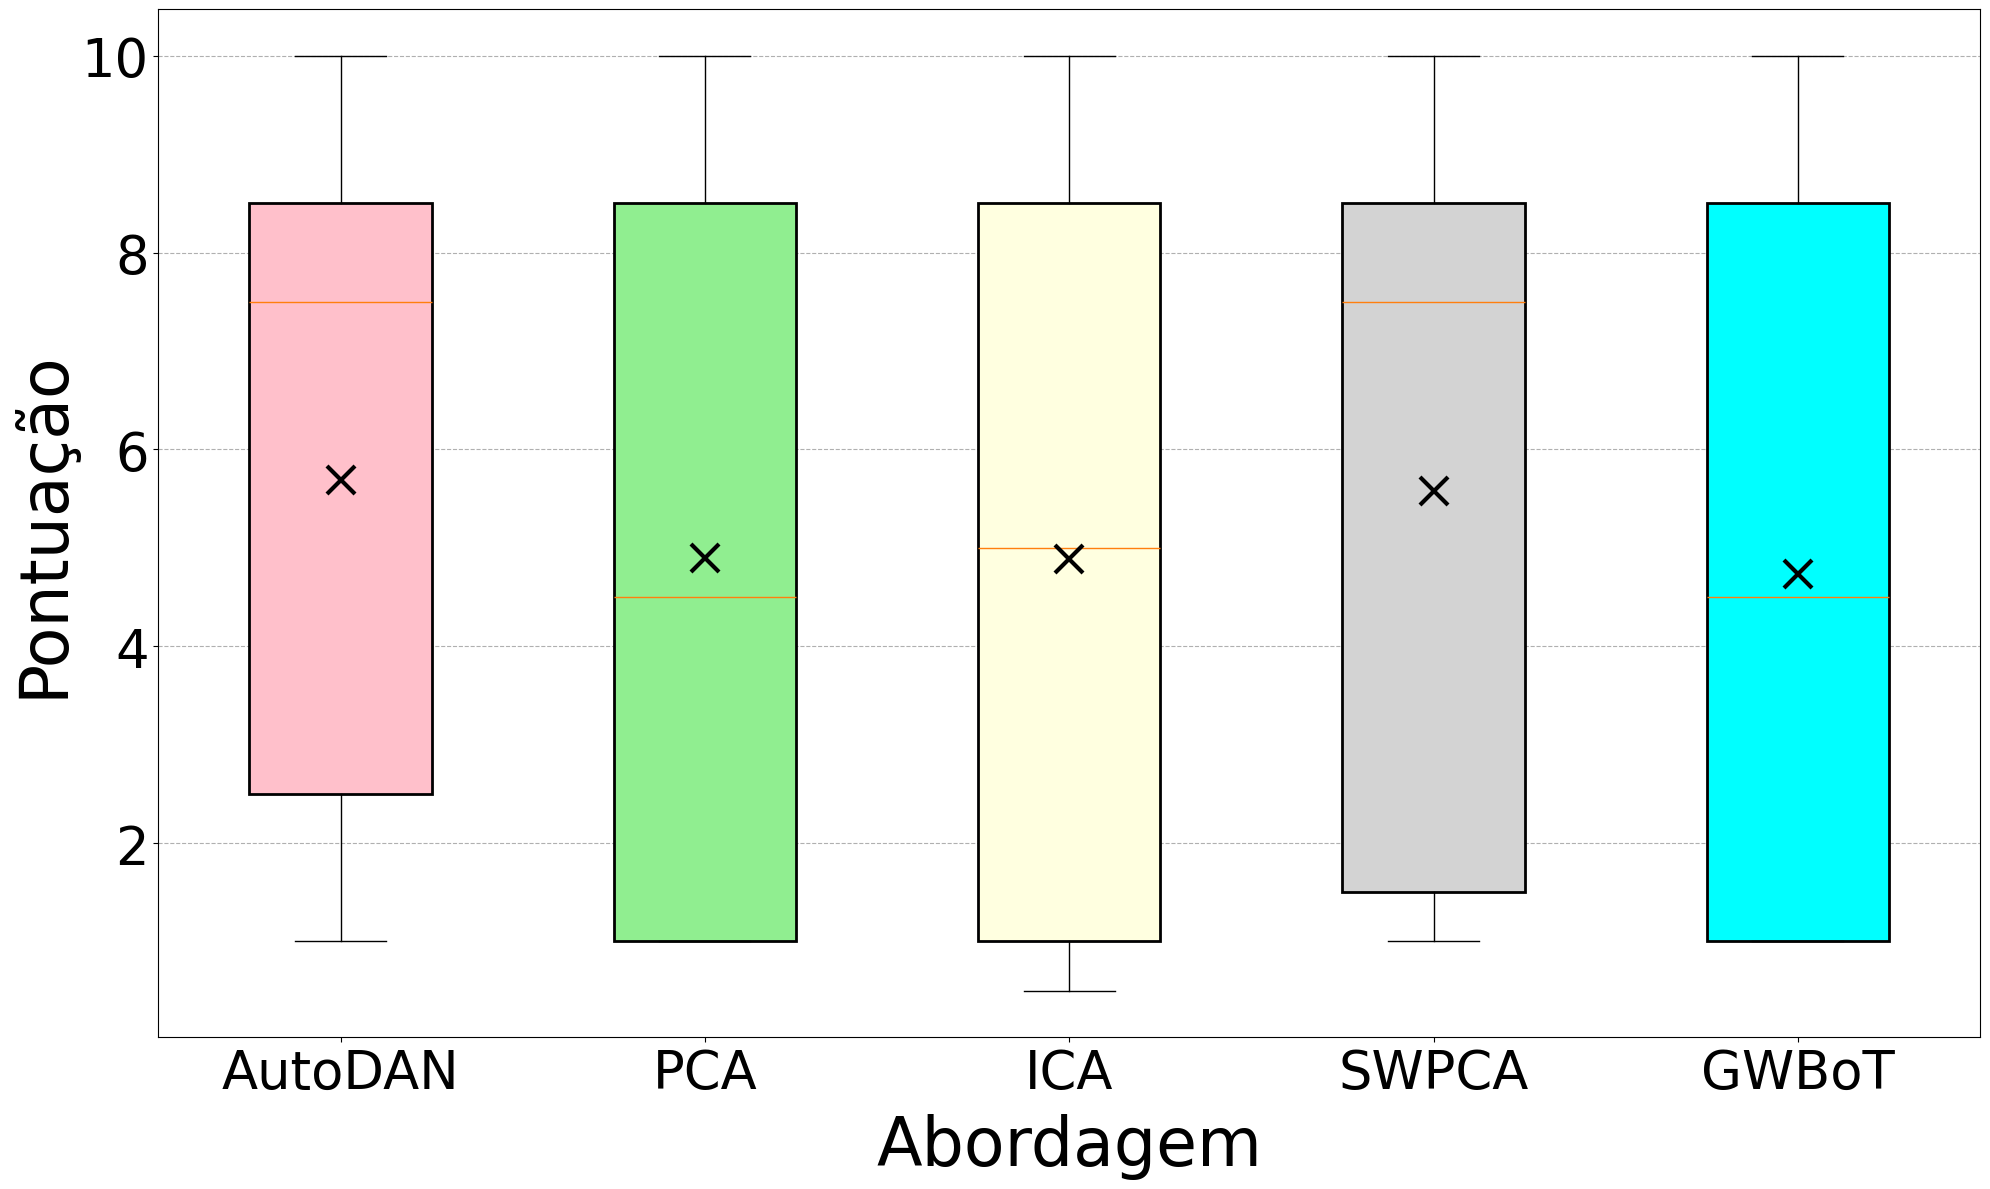

Salvo em: images/scores_comparison_boxplot_.pdf


In [1]:
import json
import matplotlib.pyplot as plt
import os

# Create directory if it doesn't exist (safety check)

# Load files
try:
    with open("attack_logs.json", "r") as f:
        autodan_data = json.load(f)
    # ===== Certifique-se de que o nome do arquivo aqui é o correto =====
    with open("final_results_semish.json", "r") as f:
        methods_data = json.load(f)
except FileNotFoundError:
    print("Erro: Arquivos JSON não encontrados. Certifique-se de que estão na pasta correta.")
    autodan_data = []
    methods_data = {}

# Get method keys to decide on renaming
method_keys = list(methods_data.keys())
print("Method keys found:", method_keys) # Isso é só um aviso, não é erro!

# Define a mapping for better display
name_mapping = {
    'pca': 'PCA',
    'ica': 'ICA',
    'score_weighted_pca': 'SWPCA',
    'gradient_weighted': 'GWBoT',
}

def format_label(key):
    if key in name_mapping:
        return name_mapping[key]
    return key.replace('_', ' ').title()

# Extract scores
data_to_plot = []
labels = []

# 1. AutoDAN
autodan_scores = [entry.get('score', 0) for entry in autodan_data if 'score' in entry]
if autodan_scores: # Só adiciona se não for vazio
    data_to_plot.append(autodan_scores)
    labels.append("AutoDAN")

# 2. Other Approaches
ordered_keys = ['pca', 'ica', 'score_weighted_pca', 'gradient_weighted']
extra_keys = [k for k in method_keys if k not in ordered_keys]

for method_name in ordered_keys + extra_keys:
    if method_name in methods_data:
        method_content = methods_data[method_name]
        method_scores = []
        for key, entry in method_content.items():
            if isinstance(entry, dict):
                
                # ---- SOLUÇÃO AQUI ----
                # 1. Tenta pegar 'scores' diretamente (funciona para o arquivo 1)
                if 'scores' in entry and len(entry['scores']) > 0:
                    method_scores.extend(entry['scores'])
                
                # 2. Se a lista principal estiver vazia, procura dentro de 'targets' (funciona para o arquivo 2)
                elif 'targets' in entry:
                    for model_name, model_data in entry['targets'].items():
                        if 'scores' in model_data and len(model_data['scores']) > 0:
                            method_scores.extend(model_data['scores'])
                # -----------------------
        
        # Evita travar o Matplotlib: só adiciona se realmente encontrou pontuações
        if method_scores:
            data_to_plot.append(method_scores)
            labels.append(format_label(method_name))

# Plotting
if not data_to_plot:
    print("Nenhum dado válido de pontuação foi encontrado para plotar.")
else:
    plt.figure(figsize=(20, 12))

    bplot = plt.boxplot(data_to_plot, patch_artist=True, labels=labels,
                        showmeans=True,
                        meanprops={
                            "marker": "x", 
                            "markeredgecolor": "black", 
                            "markersize": 20, 
                            "markeredgewidth": 3
                        })

    colors = ['pink', 'lightgreen', 'lightyellow', 'lightgrey', 'cyan', 'orange', 'purple']
    for i, patch in enumerate(bplot['boxes']):
        color = colors[i % len(colors)]
        patch.set_facecolor(color)
        patch.set_linewidth(2)

    plt.ylabel('Pontuação', fontsize=48)
    plt.xlabel('Abordagem', fontsize=48, labelpad=10)
    plt.grid(True, axis='y', linestyle='--')
    plt.xticks(rotation=0, fontsize=38)
    plt.yticks(fontsize=38)

    output_filename = 'images/scores_comparison_boxplot_.pdf'
    plt.tight_layout()
    plt.savefig(output_filename)
    plt.show()
    print(f"Salvo em: {output_filename}")